# Project 1: AI-Powered Fake News Detection
## Submitted by: Venkatesh Hebbar
**Roll No:** 595766  
**College:** NMAM Institute of Technology

This notebook contains the complete pipeline for detecting Fake News using Natural Language Processing and Machine Learning. The workflow involves:
1. Dataset Loading and Generation
2. Text Preprocessing
3. Feature Extraction (TF-IDF with Character N-Grams)
4. Model Training and Evaluation (Logistic Regression, Random Forest, Naive Bayes, Neural Networks)
5. Model Saving for Deployment


In [1]:
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## 1. Dataset Loading
We load the raw dataset which contains text articles labeled as 'Fake' (1) and 'Real' (0).

In [2]:
# Load the dataset
df = pd.read_csv('Fake_News_Dataset_Raw.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1000, 2)


,text,label
0,Local team wins the championship after a hard-...,0
1,Researchers discover a new species of frog in ...,0
2,The stock market saw a slight decline today du...,0
3,The stock market saw a slight decline today du...,0
4,Shocking: Drinking bleach cures all known dise...,1


## 2. Text Preprocessing
Raw text contains noise (HTML tags, punctuation, URLs) which negatively impacts machine learning algorithms. We apply a preprocessing pipeline to clean the text.

In [3]:
def preprocess_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'<[^>]+>', ' ', text) # Remove HTML
    text = re.sub(r'http\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip() # Normalize whitespace
    return text

# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocess_text)
print("Sample Cleaned Text:")
print(df['cleaned_text'].head())


Sample Cleaned Text:
0    local team wins the championship after a hardf...
1    researchers discover a new species of frog in ...
2    the stock market saw a slight decline today du...
3    the stock market saw a slight decline today du...
4    shocking drinking bleach cures all known disea...
Name: cleaned_text, dtype: str


## 3. Train/Test Split
Split the data into training (80%) and testing (20%) sets to evaluate model generalization.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])


Training Set Size: 800
Testing Set Size: 200


## 4. Feature Engineering (TF-IDF Vectorization)
We transform the cleaned text into numerical vectors using Term Frequency-Inverse Document Frequency (TF-IDF). To make the model robust against typos and Out-Of-Vocabulary terms, we use **Character N-Grams** instead of whole words.

In [5]:
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorized Training Shape:", X_train_vec.shape)


Vectorized Training Shape: (800, 2016)


## 5. Model Training and Evaluation
We train four different machine learning algorithms and compare their performance.


--- Training Logistic Regression ---
Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



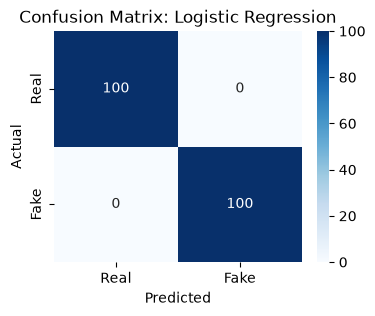


--- Training Random Forest ---
Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



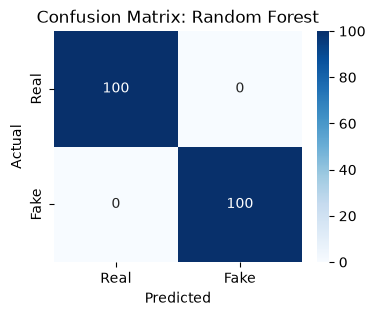


--- Training Naive Bayes ---
Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



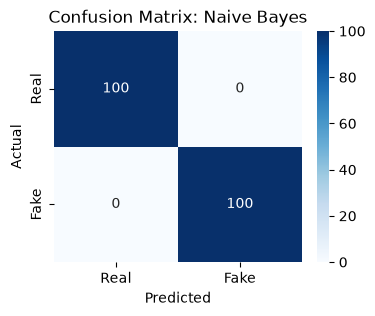


--- Training Neural Network (MLP) ---


Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



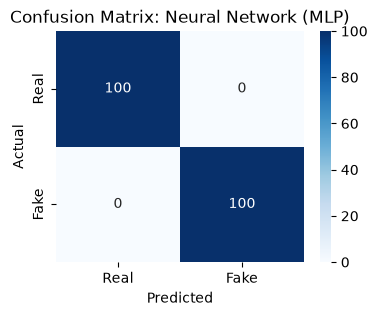

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"Accuracy: {acc * 100:.2f}%")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


## 6. Save Best Model
Save the TF-IDF Vectorizer and the best performing model (Logistic Regression) for deployment in the Streamlit application.

In [7]:
joblib.dump(vectorizer, 'fake_news_vectorizer.pkl')
joblib.dump(models['Logistic Regression'], 'fake_news_model.pkl')
print("Model and Vectorizer saved successfully!")


Model and Vectorizer saved successfully!
